# Quantile crossing analysis

In [1]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [2]:
from src.models import (
    LSTMForecaster, 
    MLPForecaster, 
    LinearForecaster, 
    NaiveGaussian, 
    NaiveBootstrap, 
    TransfomerForecaster, 
    GPForecaster,
)
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from eth_utils import print_metrics, plot_quantile_forecast, plot_quantile_levels, print_crossing_ratio

import warnings
warnings.filterwarnings("ignore")

## Downloading dataset

In [3]:
binance_ethusd_2024 = pd.read_csv('../data/raw/Binance_ETHUSDT_2024_minute.csv', skiprows=1)
binance_ethusd_2024.Date = pd.to_datetime(binance_ethusd_2024.Date)
binance_ethusd_2024 = binance_ethusd_2024.sort_values(by='Date')
binance_ethusd_2024 = binance_ethusd_2024.set_index('Date')
binance_ethusd_2024 = binance_ethusd_2024[['High', 'Low']]
binance_ethusd_2024.head()

,High,Low
Date,,
2024-01-01 00:00:00,2282.94,2281.27
2024-01-01 00:01:00,2283.97,2282.20
2024-01-01 00:02:00,2284.60,2283.80
2024-01-01 00:03:00,2286.43,2284.38
2024-01-01 00:04:00,2287.84,2286.37


In [4]:
binance_ethusd_2024.shape

(526738, 2)

In [5]:
l = len(binance_ethusd_2024)
target = binance_ethusd_2024.values
split = 0.7

In [6]:
scaler = StandardScaler()
target[:int(l*split)] = scaler.fit_transform(target[:int(l*split)])
target[int(l*split):] = scaler.transform(target[int(l*split):])

In [7]:
target = torch.tensor(target, dtype=torch.float32)
train_target = target[:int(l*split)]
test_target = target[int(l*split):]

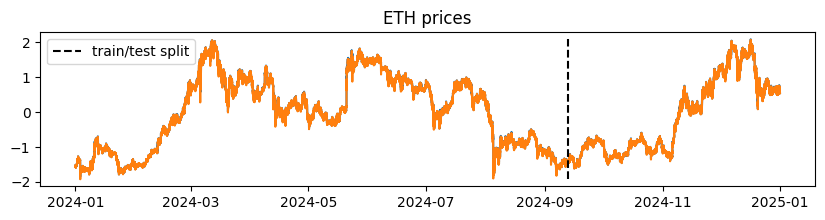

In [8]:
min_, max_ = target.min(), target.max()
plt.figure(figsize=(10, 2))
plt.plot(binance_ethusd_2024.index, target)
plt.vlines(binance_ethusd_2024.index[int(l*split)], min_, max_, linestyles='dashed', color='black', label='train/test split')
plt.title('ETH prices')
plt.legend()
plt.show()

## Allowing quantile crossing

In [9]:
quantile_levels = np.arange(0.025, 1., 0.025)
quantile_levels

array([0.025, 0.05 , 0.075, 0.1  , 0.125, 0.15 , 0.175, 0.2  , 0.225,
       0.25 , 0.275, 0.3  , 0.325, 0.35 , 0.375, 0.4  , 0.425, 0.45 ,
       0.475, 0.5  , 0.525, 0.55 , 0.575, 0.6  , 0.625, 0.65 , 0.675,
       0.7  , 0.725, 0.75 , 0.775, 0.8  , 0.825, 0.85 , 0.875, 0.9  ,
       0.925, 0.95 , 0.975])

In [10]:
model = LSTMForecaster.load_from_checkpoint(
    checkpoint_path='eth_checkpoints/lstm_quantile_crossing.ckpt',
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=quantile_levels.tolist(),
    step_size=30,
    batch_size=32,
    num_epochs=10,
    num_layers=1,
    lr=0.001, 
    hidden_dim=128,
)

In [11]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

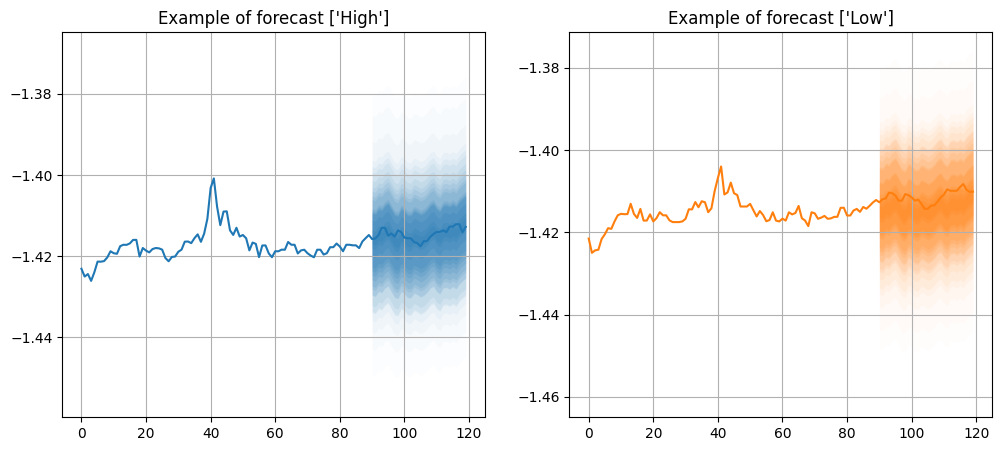

PICP: 0.9513
ECE: 0.0143
CRPS: 0.0392


In [12]:
plot_quantile_forecast(model, test_dataset, binance_ethusd_2024.columns, idx=0)
metrics = print_metrics(model, test_dataset)

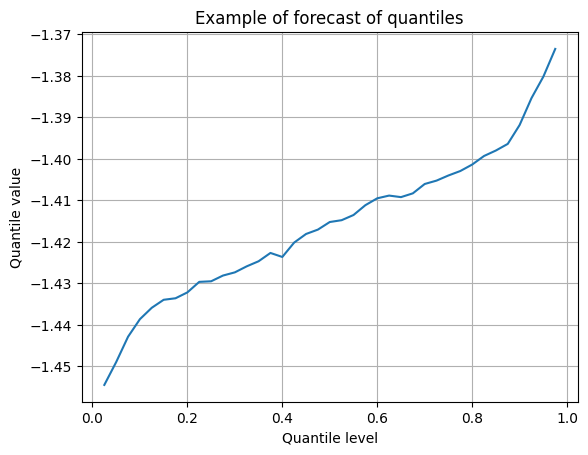

Quantile crossing ratio: 0.0526


In [13]:
plot_quantile_levels(model, test_dataset, idx=0)
print_crossing_ratio(model, test_dataset, idx=0)

## Preventing quantile crossing

In [14]:
model = LSTMForecaster.load_from_checkpoint(
    checkpoint_path="eth_checkpoints/lstm_prevent_quantile_crossing.ckpt",
    input_len=90, 
    output_len=30, 
    target_dim=2, 
    quantile_levels=quantile_levels.tolist(),
    step_size=30,
    batch_size=64,
    num_epochs=10,
    num_layers=1,
    lr=0.001, 
    hidden_dim=128,
    prevent_crossing=True,
)

In [15]:
train_dataset = model.transform(train_target)
test_dataset = model.transform(test_target)

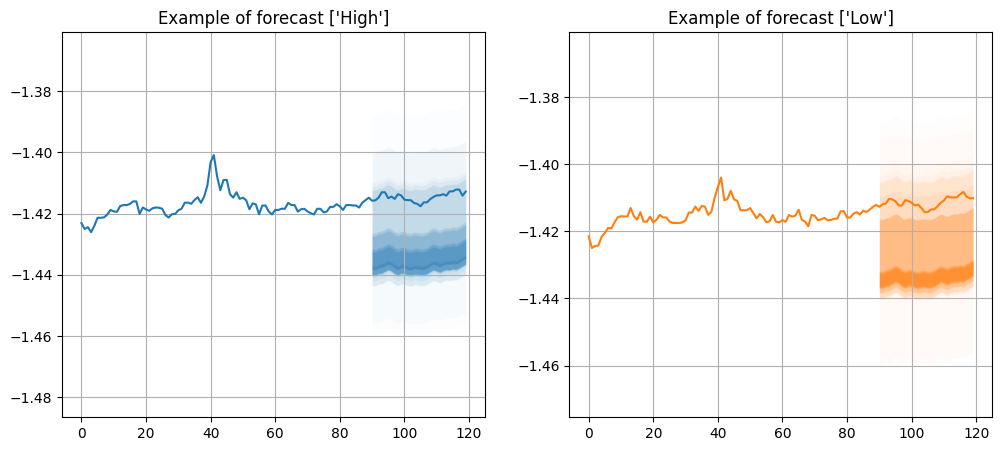

PICP: 0.9698
ECE: 0.0582
CRPS: 0.0567


In [16]:
idx = 0
input_range = range(0, model.input_len)
output_range = range(model.input_len, model.input_len + model.output_len)
full_range = range(0, model.input_len + model.output_len)

input_seq, output_seq = test_dataset[idx]
output_seq = output_seq[None, -model.output_len:]
input_seq = input_seq[None, :, :]
full_seq = torch.cat([input_seq, output_seq], dim=1)
predicted_seq = model.predict(input_seq)

plt.figure(figsize=(12, 5))
for c, color in enumerate(['tab:blue', 'tab:orange']):
    plt.subplot(1, 2, c+1)
    plt.plot(full_range, full_seq[0, :, c], color=color)
    for i in range(len(model.quantile_levels) // 2):
        alpha = model.quantile_levels[-i-1] - model.quantile_levels[i]
        plt.fill_between(
            output_range, 
            predicted_seq[0, :, c, i], 
            predicted_seq[0, :, c, -i-1], 
            alpha=i*0.01, 
            label=f'forecast High confidence {alpha:.2f}', 
            color=color,
            lw=0,
    )
    plt.title(f'Example of forecast {[binance_ethusd_2024.columns[c]]}')
    plt.grid()
plt.show()
metrics = print_metrics(model, test_dataset)

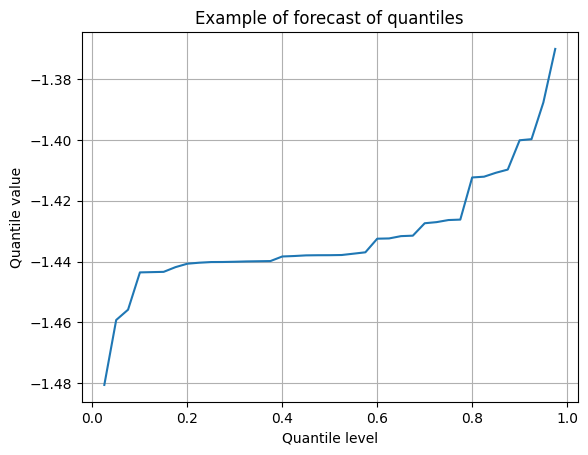

Quantile crossing ratio: 0.0000


In [17]:
plot_quantile_levels(model, test_dataset, idx=0)
print_crossing_ratio(model, test_dataset, idx=0)